# Task 3

## Task 3.1.

In [4]:
import HMM_inference
from HMM_models import RampModelHMM
import numpy as np

Newver


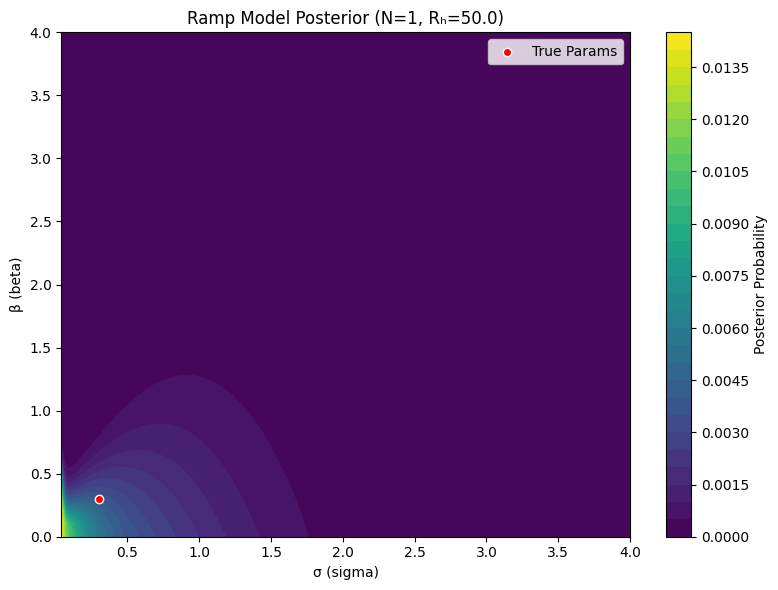

Newver


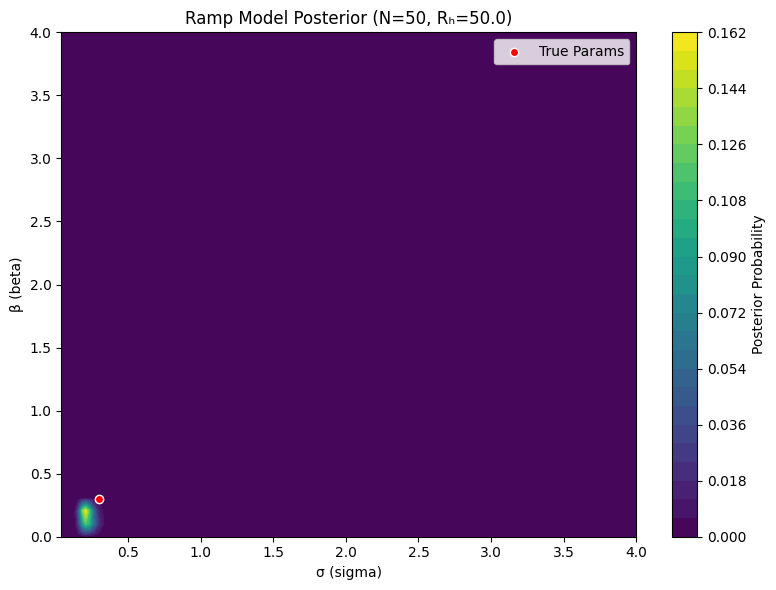

Newver


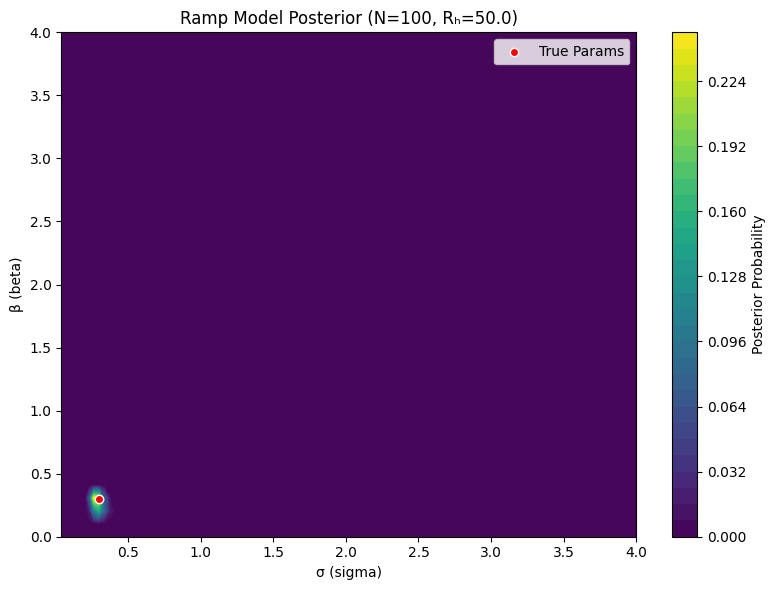

Newver


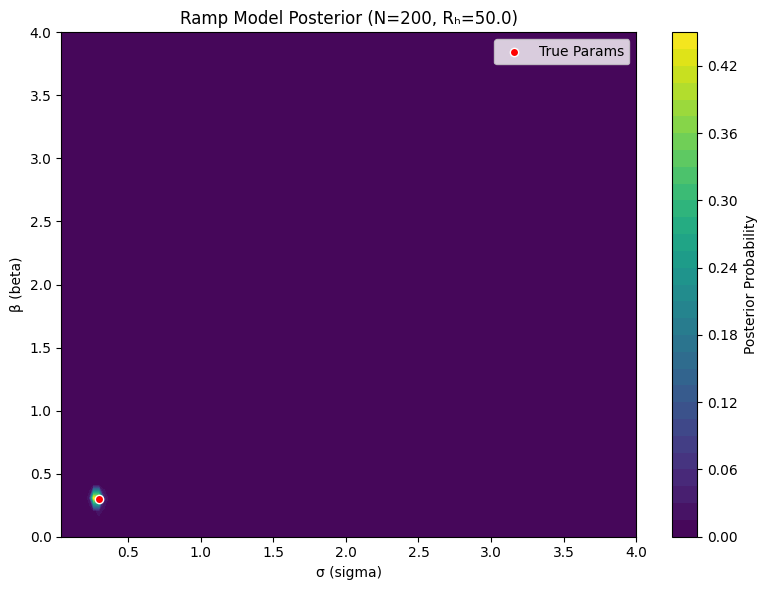

Newver


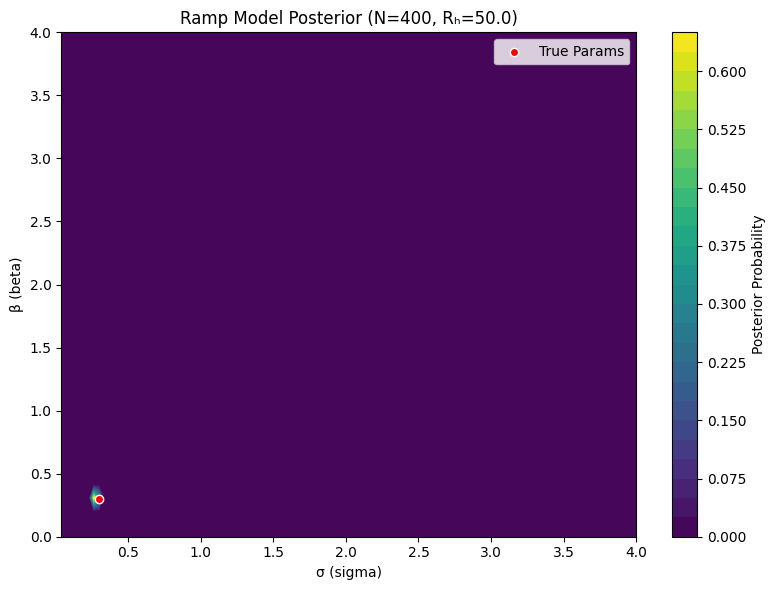

In [ ]:
# set x0 = 0.2
ramp = RampModelHMM(beta=0.3, sigma=0.3, dt=0.01)
K  = ramp.K
s0 = round(0.2*(K-1))
pi0 = np.zeros(K); pi0[s0] = 1.0

# build a grid uniform in ln sigma
lnsigma_vals = np.linspace(np.log(0.04), np.log(4.0), 40)
sigma_vals   = np.exp(lnsigma_vals)

# inference varying N
for c in [1, 50, 100, 200, 400]:
    posterior, beta_vals, sigma_vals = HMM_inference.ramp_grid_inference_optimized(
        true_beta   = 0.3,
        true_sigma  = 0.3,
        dt = 0.01,
        N           = c,
        M           = 40,
        n_jobs      = 4,
        beta_range  = (0.0, 4.0),
        sigma_range = (0.04, 4.0)     
    )

# inference varying beta and sigma
for c in [0,2,4]:
    for a in [0.04, 0.4, 4]
        posterior, beta_vals, sigma_vals = HMM_inference.ramp_grid_inference(
            true_beta   = c,
            true_sigma  = a,
            dt = 0.01,
            N           = 100,
            M           = 40,
            n_jobs      = 4,
            beta_range  = (0.0, 4.0),
            sigma_range = (0.04, 4.0)     
        )

Newver


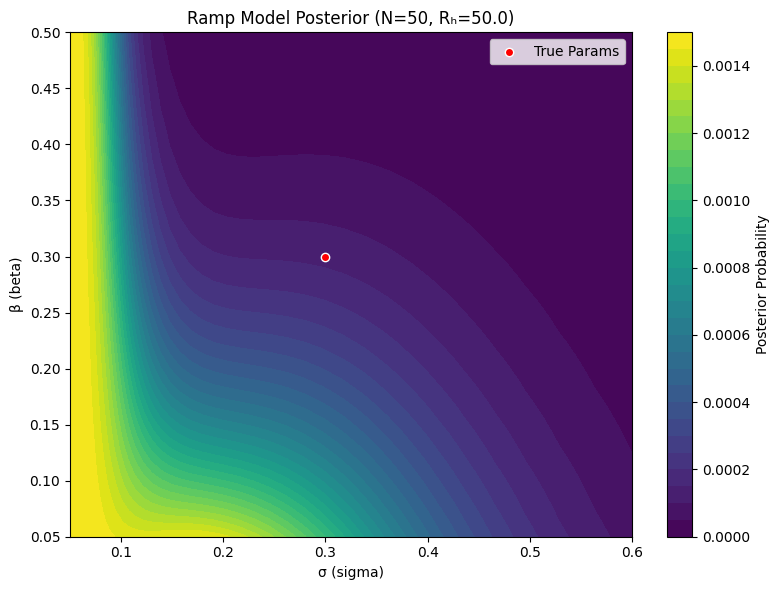

         25868093 function calls (25857439 primitive calls) in 170.491 seconds

   Ordered by: internal time
   List reduced from 2063 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   313796   37.447    0.000  124.693    0.000 _distn_infrastructure.py:2044(cdf)
     2158   25.877    0.012   25.877    0.012 {built-in method time.sleep}
   710828   11.449    0.000   11.449    0.000 {method 'reduce' of 'numpy.ufunc' objects}
   313805    9.686    0.000   12.232    0.000 _stride_tricks_impl.py:349(_broadcast_to)
    78449    9.421    0.000  139.001    0.002 HMM_models.py:67(_calculate_transition_probs)
   313796    7.563    0.000   12.770    0.000 _distn_infrastructure.py:982(_open_support_mask)
   313796    7.471    0.000   46.690    0.000 _distn_infrastructure.py:561(argsreduce)
   941388    5.702    0.000    5.702    0.000 {built-in method numpy._core._multiarray_umath._place}
   627799    5.153    0.000   19.530    0.000 fromnume

In [9]:
import cProfile
import pstats
from io import StringIO

pr = cProfile.Profile()
pr.enable()

# Run the grid inference function
HMM_inference.ramp_grid_inference_optimized(
    true_beta=0.3,
    true_sigma=0.3,
    N=50,
    M=40,
)
pr.disable()

# Process stats
s = StringIO()
ps = pstats.Stats(pr, stream=s).strip_dirs().sort_stats("tottime")
ps.print_stats(20)  # Show top 20

# Display
print(s.getvalue())
